In [1]:
# Ensure required plotting packages are available
# %pip install --quiet plotly

# Data manipulation
# ==============================================================================
import pandas as pd
import numpy as np

import datetime

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from skforecast import plot
plot.set_dark_theme()


# Modelling and Forecasting
# ==============================================================================
import sklearn
import skforecast
import lightgbm
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# warnings
# ==============================================================================
import warnings
from skforecast.exceptions import LongTrainingWarning
warnings.filterwarnings("once")
warnings.simplefilter('ignore', category=LongTrainingWarning)

color = "\033[1m\033[38;5;208m"
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version scikit-learn: {sklearn.__version__}")
print(f"{color}Version lightgbm: {lightgbm.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

Version skforecast: 0.19.1
Version scikit-learn: 1.8.0
Version lightgbm: 4.6.0
Version pandas: 2.3.3
Version numpy: 2.3.5


/Users/miguelfonseca/venvs/mpaaaf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Data download
# ==============================================================================
data = pd.read_csv(
    "https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/bitcoin.csv"
)
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data = data.asfreq('D')
data

,open,high,low,close,volume,market cap
date,,,,,,
2013-04-28,128.000100,128.000100,128.000100,128.000100,0.000000e+00,1.418304e+09
2013-04-29,134.444400,135.980000,132.100000,134.210000,0.000000e+00,1.488338e+09
2013-04-30,134.444000,147.488000,134.000000,144.540000,0.000000e+00,1.549501e+09
2013-05-01,144.000000,146.930000,134.050000,139.000000,0.000000e+00,1.578685e+09
2013-05-02,139.000000,139.890000,107.720000,116.990000,0.000000e+00,1.422546e+09
...,...,...,...,...,...,...
2021-12-28,50787.263830,51950.912600,50459.263641,50650.171445,4.695844e+10,9.655866e+11
2021-12-29,50667.988338,50667.988338,47411.717237,47637.888400,5.939821e+10,9.241336e+11
2021-12-30,47547.865500,48112.021472,46272.662981,46408.302671,8.826973e+10,8.998872e+11


In [3]:
print(f'Number of rows with missing values: {data.isnull().any(axis=1).mean()}')

Number of rows with missing values: 0.0


In [4]:
# Dict with Bitcoin halvings info
# ==============================================================================
btc_halving = {
    "halving": [0, 1, 2, 3, 4],
    "date": ["2009-01-03", "2012-11-28", "2016-07-09", "2020-05-11", np.nan],
    "reward": [50, 25, 12.5, 6.25, 3.125],
    "halving_block_number": [0, 210000, 420000, 630000, 840000],
}

In [5]:
# Next halving calculation
# The remaining blocks according to the coinmarketcap.com website for 
# the next halving as of 2022-01-14 are taken as a starting point
# ==============================================================================
remaining_blocks = 121400
blocks_per_day = 144
days = remaining_blocks / blocks_per_day
next_halving = pd.to_datetime('2022-01-14', format='%Y-%m-%d') + datetime.timedelta(days=days)
next_halving = next_halving.replace(microsecond=0, second=0, minute=0, hour=0)
next_halving = next_halving.strftime('%Y-%m-%d')
btc_halving['date'][-1] = next_halving

print(f'The next halving will occur on approximately: {next_halving}')

The next halving will occur on approximately: 2024-05-06


In [6]:
# Include rewards and countdown to next halving in dataset
# ==============================================================================
data["reward"] = np.nan
data["countdown_halving"] = np.nan

for i in range(len(btc_halving["halving"]) - 1):

    # Start and end date of each halving
    if btc_halving["date"][i] < data.index.min().strftime("%Y-%m-%d"):
        start_date = data.index.min().strftime("%Y-%m-%d")
    else:
        start_date = btc_halving["date"][i]

    end_date = btc_halving["date"][i + 1]
    mask = (data.index >= start_date) & (data.index < end_date)

    # Fill column 'reward' with mining rewards
    data.loc[mask, "reward"] = btc_halving["reward"][i]

    # Fill column 'countdown_halving' with remaining days
    time_to_next_halving = pd.to_datetime(end_date) - pd.to_datetime(start_date)

    data.loc[mask, "countdown_halving"] = np.arange(time_to_next_halving.days)[::-1][
        : mask.sum()
    ]

In [7]:
# Check that the data have been created correctly
# ==============================================================================
print("Second halving:", btc_halving["date"][2])
display(data.loc["2016-07-08":"2016-07-09"])
print("")
print("Third halving:", btc_halving["date"][3])
display(data.loc["2020-05-10":"2020-05-11"])
print("")
print("Next halving:", btc_halving["date"][4])
data.tail(2)


Second halving: 2016-07-09


,open,high,low,close,volume,market cap,reward,countdown_halving
date,,,,,,,,
2016-07-08,677.331,682.432,611.834,639.667,1.892361e+08,1.015055e+10,25.0,0.0
2016-07-09,640.562,666.707,636.467,666.707,2.061508e+08,1.020561e+10,12.5,1401.0



Third halving: 2020-05-11


,open,high,low,close,volume,market cap,reward,countdown_halving
date,,,,,,,,
2020-05-10,9814.400817,9900.431521,9559.705894,9570.005988,3.675906e+10,1.786858e+11,12.50,0.0
2020-05-11,9554.216377,9554.216377,8388.959555,8745.152545,4.909643e+10,1.598261e+11,6.25,1455.0



Next halving: 2024-05-06


,open,high,low,close,volume,market cap,reward,countdown_halving
date,,,,,,,,
2021-12-31,46430.481224,47876.491839,46077.722276,47161.009200,1.229248e+11,8.907742e+11,6.25,856.0
2022-01-01,47139.359000,48505.999700,45712.566592,46304.949594,7.810027e+10,8.945653e+11,6.25,855.0


In [8]:
# Locate corresponding data for each year
# ==============================================================================
years = list(data.index.year.unique())
df_plot = pd.DataFrame()

for year in years:

    year_open = data.loc[data.index.year == year, "open"].iloc[0]
    year_close = data.loc[data.index.year == year, "close"].iloc[-1]
    year_low = data.loc[data.index.year == year, "low"].min()
    year_high = data.loc[data.index.year == year, "high"].max()

    df_plot[year] = pd.Series([year_open, year_close, year_low, year_high])

df_plot = df_plot.T
df_plot = df_plot.set_axis(["open", "close", "low", "high"], axis=1)

# Calculate % change between the open and close price of the year
# ==============================================================================
df_plot["year_change"] = 100 * (df_plot["close"] - df_plot["open"]) / df_plot["open"]
df_plot.head(3)

,open,close,low,high,year_change
2013,128.0001,756.130,65.526,1156.140,490.726101
2014,760.3200,310.610,289.296,1017.120,-59.147464
2015,310.7370,426.371,171.510,495.562,37.212820


In [9]:
# Interactive candlestick chart with Plotly
# ==============================================================================
candlestick = go.Candlestick(
    x=data.index,
    open=data.open,
    close=data.close,
    low=data.low,
    high=data.high,
)

fig = go.Figure(data=[candlestick])

fig.update_layout(
    width=750,
    height=350,
    title=dict(text="<b>Bitcoin/USD Chart</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=15)),
    margin=dict(l=10, r=20, t=80, b=20),
    shapes=[
        dict(
            x0=btc_halving["date"][2],
            x1=btc_halving["date"][2],
            y0=0,
            y1=1,
            xref="x",
            yref="paper",
            line_width=2,
        ),
        dict(
            x0=btc_halving["date"][3],
            x1=btc_halving["date"][3],
            y0=0,
            y1=1,
            xref="x",
            yref="paper",
            line_width=2,
        ),
        dict(
            x0=btc_halving["date"][4],
            x1=btc_halving["date"][4],
            y0=0,
            y1=1,
            xref="x",
            yref="paper",
            line_width=2,
        ),
    ],
    annotations=[
        dict(
            x=btc_halving["date"][2],
            y=1,
            xref="x",
            yref="paper",
            showarrow=False,
            xanchor="left",
            text="Second halving",
        ),
        dict(
            x=btc_halving["date"][3],
            y=1,
            xref="x",
            yref="paper",
            showarrow=False,
            xanchor="left",
            text="Third halving",
        ),
        dict(
            x=btc_halving["date"][4],
            y=1,
            xref="x",
            yref="paper",
            showarrow=False,
            xanchor="left",
            text="Fourth halving",
        ),
    ],
    xaxis_rangeslider_visible=False,
)

fig.show()


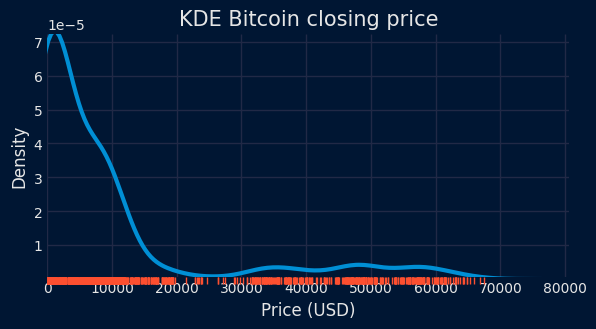

In [10]:
# KDE distribution of Bitcoin closing price
# ==============================================================================
# set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 3))
p = sns.kdeplot(data=data, x='close', linewidth=3, ax=ax)
r = sns.rugplot(data=data, x='close', ax=ax, height=-.03, clip_on=False)
p.set(xlim=(0, None))
p.set_title('KDE Bitcoin closing price', fontsize=15)
p.set_xlabel('Price (USD)');

In [11]:
# Locate corresponding data for each year
# ==============================================================================
years = list(data.index.year.unique())
df_plot = pd.DataFrame()

for year in years:

    year_open = data.loc[data.index.year == year, "open"].iloc[0]
    year_close = data.loc[data.index.year == year, "close"].iloc[-1]
    year_low = data.loc[data.index.year == year, "low"].min()
    year_high = data.loc[data.index.year == year, "high"].max()

    df_plot[year] = pd.Series([year_open, year_close, year_low, year_high])

df_plot = df_plot.T
df_plot = df_plot.set_axis(["open", "close", "low", "high"], axis=1)

# Calculate % change between the open and close price of the year
# ==============================================================================
df_plot["year_change"] = 100 * (df_plot["close"] - df_plot["open"]) / df_plot["open"]
df_plot.head(3)


,open,close,low,high,year_change
2013,128.0001,756.130,65.526,1156.140,490.726101
2014,760.3200,310.610,289.296,1017.120,-59.147464
2015,310.7370,426.371,171.510,495.562,37.212820


In [12]:
# Create a list of dicts with the % change annotations for the plot
# ==============================================================================
annotations_list = []
max_high = df_plot["high"].max()

for year in years:

    df_aux = df_plot.loc[df_plot.index == year,]
    loc_x = pd.to_datetime(df_aux.index[0], format="%Y")
    loc_y = df_aux["high"].values[0] / max_high + 0.05
    text = "{:.1f}%".format(df_aux["year_change"].values[0])

    annotation = dict(
        x=loc_x,
        y=loc_y,
        xref="x",
        yref="paper",
        showarrow=False,
        xanchor="center",
        text=text,
    )

    annotations_list.append(annotation)

# Interactive candlestick chart with Plotly
# ==============================================================================
candlestick = go.Candlestick(
    x=pd.to_datetime(df_plot.index, format="%Y"),
    open=df_plot.open,
    close=df_plot.close,
    low=df_plot.low,
    high=df_plot.high,
)

fig = go.Figure(data=[candlestick])

fig.update_layout(
    width=750,
    height=350,
    title=dict(text="<b>Bitcoin/USD yearly chart</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
    xaxis_rangeslider_visible=False,
    annotations=annotations_list,
)

fig.show()


In [13]:
# Locate corresponding data for each month
# ==============================================================================
years = list(data.index.year.unique())
df_plot = pd.DataFrame()

for year in years:
    for month in range(12):

        start_date = pd.to_datetime(f"{year}-{month+1}-01", format="%Y-%m-%d")
        end_date = start_date + pd.offsets.MonthBegin()
        mask = (data.index >= start_date) & (data.index < end_date)

        if not data.loc[mask, :].empty:

            month_open = data.loc[mask, "open"].iloc[0]
            month_close = data.loc[mask, "close"].iloc[-1]
            month_low = data.loc[mask, "low"].min()
            month_high = data.loc[mask, "high"].max()

            serie = pd.Series([month_open, month_close, month_low, month_high])
            df_aux = pd.DataFrame(serie, columns=[f"{str(month+1).zfill(2)}-{year}"])

            if df_plot.empty:
                df_plot = df_aux.copy()
            else:
                df_plot = pd.concat([df_plot, df_aux], axis=1)

df_plot = df_plot.T
df_plot = df_plot.set_axis(["open", "close", "low", "high"], axis=1)


In [14]:
# Boxplot chart for annual seasonality
# ==============================================================================
df_plot["month"] = pd.to_datetime(df_plot.index, format="%m-%Y").month

# fig 1 monthly boxplot
fig1 = px.box(
    df_plot.sort_values("month"),
    x="month",
    y="close",
)

# fig 2 line with median data for each month
df_median = pd.DataFrame(df_plot.groupby("month")["close"].median()).reset_index()
fig2 = px.line(
    df_median,
    x="month",
    y="close",
    markers=True,
)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=650,
    height=350,
    title=dict(text="<b>BTC Price per month</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear"),
    xaxis_title=dict(text="month", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()


In [15]:
# Boxplot chart for monthly seasonality
# ==============================================================================
data["day"] = pd.Series(data.index).dt.day.values

# fig 1 dayly boxplot
fig1 = px.box(data.sort_values("day"), x="day", y="close")

# fig 2 line with median data for each day
df_median = pd.DataFrame(data.groupby("day")["close"].median()).reset_index()
fig2 = px.line(df_median, x="day", y="close", markers=True)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=750,
    height=350,
    title=dict(text="<b>BTC Price per day of the month</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear", tickangle=0, range=[0.5, 31.5]),
    xaxis_title=dict(text="day", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()


In [16]:
# Boxplot chart for weekly seasonality
# ==============================================================================
data["weekday"] = data.index.day_of_week + 1

# fig 1 weekly boxplot
fig1 = px.box(data.sort_values("weekday"), x="weekday", y="close")

# fig 2 line with median data for each weekday
df_median = pd.DataFrame(data.groupby("weekday")["close"].median()).reset_index()
fig2 = px.line(df_median, x="weekday", y="close", markers=True)

fig = go.Figure(data=fig1.data + fig2.data)

fig.update_layout(
    width=600,
    height=300,
    title=dict(text="<b>BTC Price per day of the week</b>", font=dict(size=20)),
    yaxis_title=dict(text="Price (USD)", font=dict(size=13)),
    xaxis=dict(tickmode="linear"),
    xaxis_title=dict(text="weekday", font=dict(size=13)),
    margin=dict(l=0, r=20, t=55, b=20),
)

fig.show()


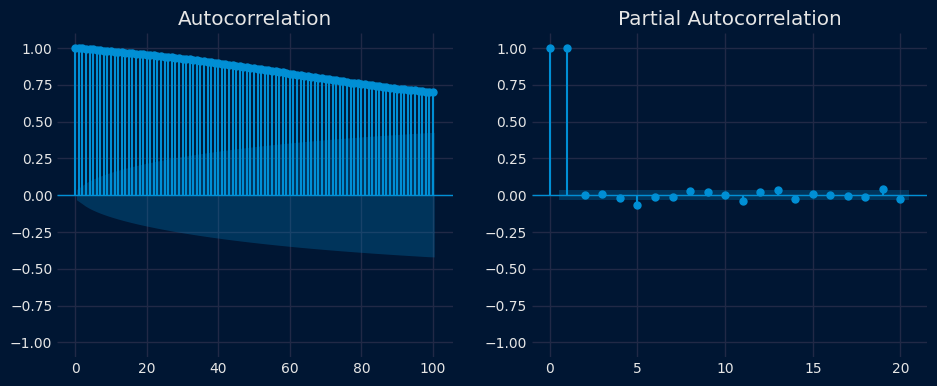

In [17]:
# Autocorrelation plots
# ==============================================================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes = axes.flat
plot_acf(data.close, ax=axes[0], linewidth = 1, lags=100)
axes[0].set_ylim(-1.1, 1.1)
plot_pacf(data.close, ax=axes[1], lags=20, method='ywm',  linewidth = 1)
axes[1].set_ylim(-1.1, 1.1)
plt.show();


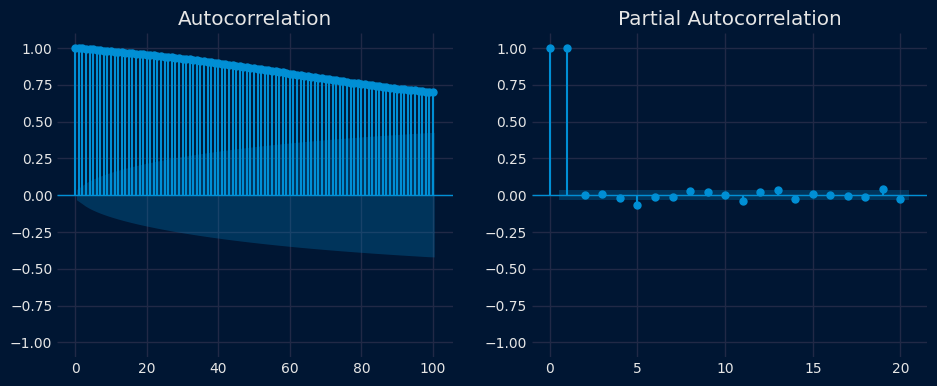

In [18]:
# Autocorrelation plots
# ==============================================================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes = axes.flat
plot_acf(data.close, ax=axes[0], linewidth = 1, lags=100)
axes[0].set_ylim(-1.1, 1.1)
plot_pacf(data.close, ax=axes[1], lags=20, method='ywm',  linewidth = 1)
axes[1].set_ylim(-1.1, 1.1)
plt.show();


In [19]:
# Selection of train-test dates
# ==============================================================================
start_train = '2020-01-01 00:00:00'
end_train = '2021-06-30 23:59:59'

print(f"Complete time series : {data.index.min()} --- {data.index.max()}  (n={len(data)})")
print(f"Train dates          : {data.loc[start_train:end_train].index.min()} --- {data.loc[start_train:end_train].index.max()}  (n={len(data.loc[start_train:end_train])})")
print(f"Test dates           : {data.loc[end_train:].index.min()} --- {data.loc[end_train:].index.max()}  (n={len(data.loc[end_train:])})")


Complete time series : 2013-04-28 00:00:00 --- 2022-01-01 00:00:00  (n=3171)
Train dates          : 2020-01-01 00:00:00 --- 2021-06-30 00:00:00  (n=547)
Test dates           : 2021-07-01 00:00:00 --- 2022-01-01 00:00:00  (n=185)


In [20]:
# Random walk simulation
# ==============================================================================
df_rw = data[['close']].copy()
df_rw['pred_close'] = df_rw['close'].shift(1)

# Test error
# ==============================================================================
y_true = df_rw.loc[end_train:, 'close']
y_pred = df_rw.loc[end_train:, 'pred_close']
metric = mean_absolute_error(y_true, y_pred)

print(f'Test error: {metric}')
display(df_rw.loc[end_train:,].head(4))


Test error: 1260.3677521425916


,close,pred_close
date,,
2021-07-01,35060.428966,35840.386468
2021-07-02,33628.670000,35060.428966
2021-07-03,33846.007087,33628.670000
2021-07-04,34698.303129,33846.007087


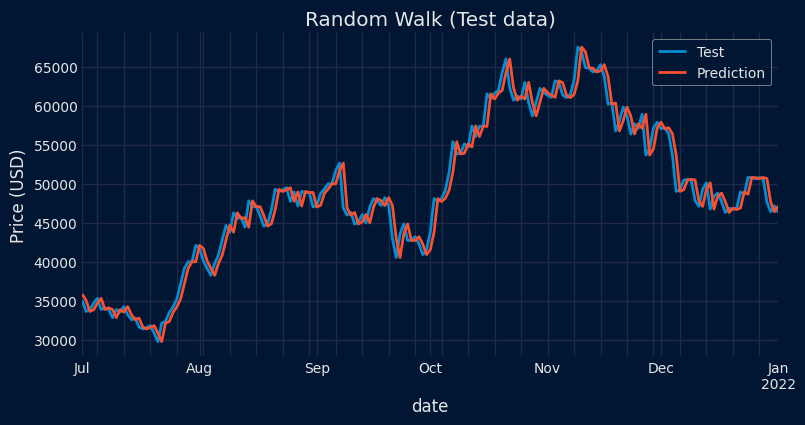

In [21]:
# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 4))
df_rw.loc[end_train:, 'close'].plot(ax=ax, linewidth=2, label='Test')
df_rw.loc[end_train:, 'pred_close'].plot(ax=ax, linewidth=2, label='Prediction')
ax.set_title('Random Walk (Test data)')
ax.set_ylabel('Price (USD)')
ax.legend();


In [22]:
# DataFrame models' test error
# ==============================================================================
df_errors = pd.DataFrame({
                'model': 'Base - Random Walk',
                'lags': 1, 
                'test_error': metric,
                'exog_variables': False
                },
                index=[0]
            )
df_errors


,model,lags,test_error,exog_variables
0,Base - Random Walk,1,1260.367752,False


In [23]:
# Forecasters backtest with different lags
# ==============================================================================
lags = [1, 7, 30]
metrics = []
predictions_list = []

for lag in lags:
    
    # Create forecaster
    forecaster = ForecasterRecursive(
                     estimator     = LGBMRegressor(random_state=123, verbose=-1),
                     lags          = lag,
                     transformer_y = None
                 )
    
    # Backtest test data, 1 step
    cv = TimeSeriesFold(
            steps              = 1,
            initial_train_size = len(data.loc[start_train:end_train, 'close']),
            fixed_train_size   = True,
            refit              = True,
         )
    metric, predictions = backtesting_forecaster(
                              forecaster         = forecaster,
                              y                  = data.loc[start_train:, 'close'],
                              cv                 = cv,
                              metric             = 'mean_absolute_error',
                              verbose            = False,
                              show_progress      = True,
                          )
    
    metrics.append(metric.at[0, 'mean_absolute_error'])
    predictions_list.append(predictions)


100%|██████████| 185/185 [00:40<00:00,  4.54it/s]


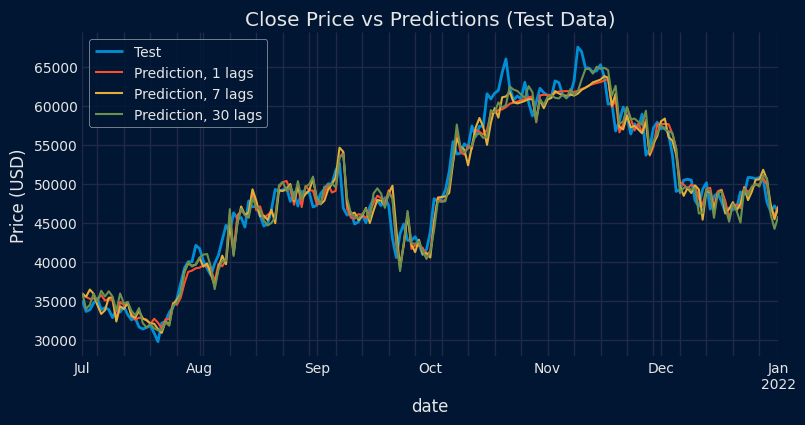

In [24]:
# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 4))
data.loc[end_train:, 'close'].plot(ax=ax, linewidth=2, label='Test')

# Plot test predictions for different lags
for predictions, lag in zip(predictions_list, lags):
    predictions = predictions.rename(columns={'pred': f'Prediction, {lag} lags'})
    predictions[f'Prediction, {lag} lags'].plot(ax=ax)

ax.set_title('Close Price vs Predictions (Test Data)')
ax.set_ylabel('Price (USD)')
ax.legend();

In [25]:
# DataFrame models' test error
# ==============================================================================
model = 'LGBMRegressor'
df_errors = pd.concat([
                df_errors,
                pd.DataFrame({
                    'model': model,
                    'lags': lags, 
                    'test_error': metrics,
                    'exog_variables': False
                })
             ]).reset_index(drop=True)
df_errors.sort_values(by='test_error')


,model,lags,test_error,exog_variables
0,Base - Random Walk,1,1260.367752,False
1,LGBMRegressor,1,1527.440787,False
2,LGBMRegressor,7,1546.268058,False
3,LGBMRegressor,30,1561.058347,False


In [26]:
# One hot encoding categorical variables
# ==============================================================================
data['month'] = data.index.month
data = pd.get_dummies(data, columns=['reward', 'month'], dtype=int)
data.head(2)


,open,high,low,close,volume,market cap,countdown_halving,day,weekday,reward_6.25,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2013-04-28,128.0001,128.0001,128.0001,128.0001,0.0,1.418304e+09,1167.0,28,7,0,...,0,1,0,0,0,0,0,0,0,0
2013-04-29,134.4444,135.9800,132.1000,134.2100,0.0,1.488338e+09,1166.0,29,1,0,...,0,1,0,0,0,0,0,0,0,0


In [27]:
# All exogenous variables are selected, including those obtained  
# during one hot encoding.
# ==============================================================================
exog = [column for column in data.columns if column.startswith(('reward', 'month'))]
exog.extend(['countdown_halving'])
exog


['reward_6.25',
 'reward_12.5',
 'reward_25.0',
 'month_1',
 'month_2',
 'month_3',
 'month_4',
 'month_5',
 'month_6',
 'month_7',
 'month_8',
 'month_9',
 'month_10',
 'month_11',
 'month_12',
 'countdown_halving']

In [28]:
# Forecaster backtest with exogenous variables
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator        = LGBMRegressor(random_state=123, verbose=-1),
                 lags             = 1,
                 transformer_y    = None,
                 transformer_exog = None
             )

# Backtest test data, 1 step
metric, predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data.loc[start_train:, 'close'],
                          exog          = data.loc[start_train:, exog],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False,
                          show_progress = True
                      )


100%|██████████| 185/185 [00:41<00:00,  4.43it/s]


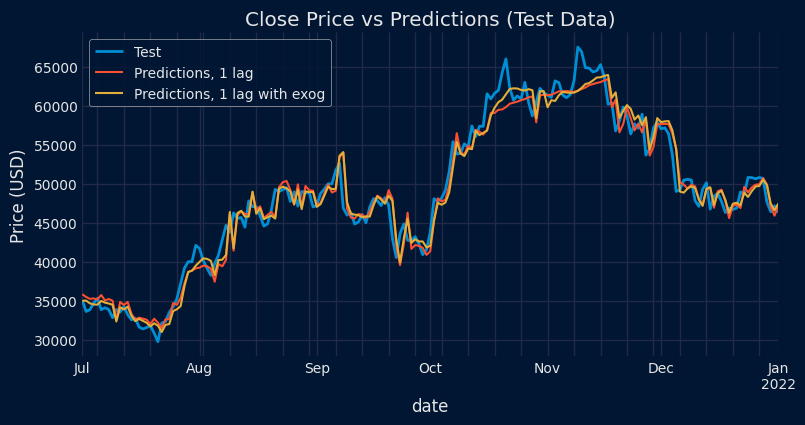

In [29]:
# Plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 4))
data.loc[end_train:, 'close'].plot(ax=ax, linewidth=2, label='Test')

# Plot predictions 1 lag without exogenous variables
predictions_no_exog = predictions_list[0].rename(columns={'pred': 'Predictions, 1 lag'})
predictions_no_exog['Predictions, 1 lag'].plot(ax=ax)

# Plot predictions 1 lag with exogenous variables
predictions_exog = predictions.rename(columns={'pred': 'Predictions, 1 lag with exog'})
predictions_exog['Predictions, 1 lag with exog'].plot(ax=ax)

ax.set_title('Close Price vs Predictions (Test Data)')
ax.set_ylabel('Price (USD)')
ax.legend();


https://cienciadedatos.net/documentos/py41-forecasting-cryptocurrency-bitcoin-machine-learning-python